# OCR: CNN

We'll train on easily accessible [NFL datasets](https://www.kaggle.com/datasets/frlemarchand/nfl-player-numbers?resource=download), and then transfer to NBA (assuming jerseys are similar in shape and color).

We can just build a lightweight CNN outputting a smoothed label distribution from [0, 00, 1-99] $\in \mathbb{R}^{101}$. The NFL data doesn't have '00', so we'll need to implement a pre-processing OCR step to gracefully handle this edge case, preventing silent failures.

1. Fast OCR (i.e. Tesseract) to see if '00' is in the image. If so, we're done.
2. If not, run through the CNN to get a smoothed label distribution for numbers 0 through 99.
3. Might need to have output be sequential cause there are missing labels, but as long as we get the digits individually, we can generate the output for any arbitrary digits (as long as the model is learning digit -> digit)

[Misc torch optimizations](https://www.reddit.com/r/MachineLearning/comments/ikr8u8/d_pytorch_performance_guide/#:~:text=Don't%20use%20apex%2C%20and,DALI%20is%20also%20really%20cool!)
- Dataloader `num_workers >0`, `pin_memory=True`
- `torch.amp`

*(12/19/2025)*. Switching to a [CRNN](https://arxiv.org/pdf/1507.05717) approach trained via CTCLoss since label distribution is too sparse with the above labels.
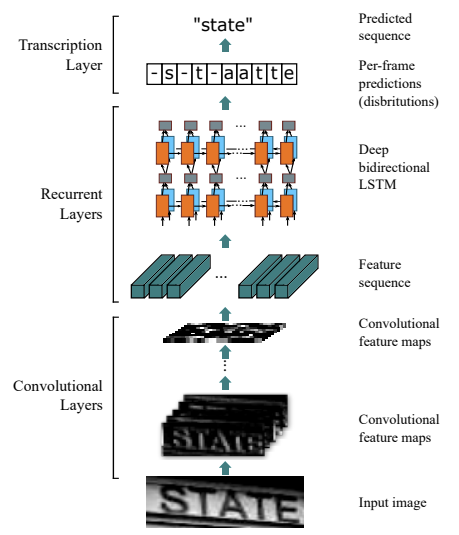

Convolutional layers will return the sequence of feature vectors from left to right. The $i$-th feature vector will be the concatenation of the $i$-th column from all the maps. Each column width is fixed to a single pixel.

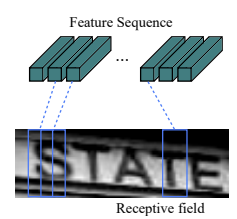

Bi-LSTM will predict label distribution $y_t$ for each from $x_t$ in the feature sequence $\mathbf{x} = x_1, \dots, x_T$. For practice, I'm going to swap the Bi-LSTM module with a transformer.

In [40]:
# colab things
from google.colab import drive
drive.mount('/content/drive')

# change working dir
%cd /content/drive/MyDrive/nba2nba/notebooks

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/nba2nba/notebooks


In [41]:
!unzip "/content/drive/MyDrive/nba2nba/data/.cache/nfl_jersey_numbers.zip" -d "/content"

Streaming output truncated to the last 5000 lines.
  inflating: /content/train_player_numbers/58095_004022_Endzone_360_V90.png  
  inflating: /content/train_player_numbers/58095_004022_Endzone_380_H6.png  
  inflating: /content/train_player_numbers/58095_004022_Endzone_380_H64.png  
  inflating: /content/train_player_numbers/58095_004022_Endzone_380_H77.png  
  inflating: /content/train_player_numbers/58095_004022_Endzone_380_H78.png  
  inflating: /content/train_player_numbers/58095_004022_Endzone_380_H80.png  
  inflating: /content/train_player_numbers/58095_004022_Endzone_380_H85.png  
  inflating: /content/train_player_numbers/58095_004022_Endzone_380_H89.png  
  inflating: /content/train_player_numbers/58095_004022_Endzone_380_V23.png  
  inflating: /content/train_player_numbers/58095_004022_Endzone_380_V30.png  
  inflating: /content/train_player_numbers/58095_004022_Endzone_380_V50.png  
  inflating: /content/train_player_numbers/58095_004022_Endzone_380_V57.png  
  inflating: /

## Installs + Imports

In [42]:
# import mlflow
import os
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import math

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.io import decode_image
from torchvision.transforms import v2
from torchsummary import summary

from contextlib import ExitStack
from sklearn.model_selection import train_test_split

from tqdm.notebook import tqdm


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# jersey_path = "../data/.cache/nfl_jersey_numbers"
jersey_path = "/content"
NUM_CLASSES = 100
MAX_GRAD_NORM = 1
# mlflow.set_tracking_uri("sqlite:///../mlflow.db")
# mlflow.set_experiment("jersey_ocr")

In [43]:
print(f"CUDA: {torch.cuda.is_available()}")

CUDA: True


## Helpers

In [76]:
def collate_fn(batch):
    """
    Dataloader collate fn for sequences in batch to make them the same length
    """

    # batch will be list of tuples where batch[0] is (im1, label1, seq_len1)
    # we want to set images = [im1, im2, ...], labels=...
    images, labels, seq_lens = zip(*batch) # = zip(batch[0], batch[1], batch[2])
    images = torch.stack(images, 0) # same size
    labels_padded = nn.utils.rnn.pad_sequence(labels,
                                              batch_first=True,
                                              # pad with blanks
                                              padding_value = 0)
    seq_lens = torch.tensor(seq_lens)
    return images, labels_padded, seq_lens

In [77]:
def calculate_cmat(y_true, y_pred, n_classes):
    """
    Calculate confusion matrix.

    - Diags are TP counts
    - cmat.sum(axis = 1) would give TP + FN since it counts all the y_true = class
    - cmat.sum(axis = 0) would give TP + FP since it counts all the y_pred = class
    """
    cm = torch.zeros((n_classes, n_classes))
    for i in range(n_classes):
        for j in range(n_classes):
            cm[i, j] = torch.sum((y_true == i) & (y_pred == j))
    return cm
a = calculate_cmat(torch.tensor([1, 2, 3, 2, 1, 1, 2, 0]), torch.tensor([1, 2, 3, 1, 1, 3, 3, 0]), 5)
a

tensor([[1., 0., 0., 0., 0.],
        [0., 2., 0., 1., 0.],
        [0., 1., 1., 1., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0.]])

In [78]:
a.sum(axis=0)

tensor([1., 3., 1., 3., 0.])

In [79]:
torch.full((10,), 5)

tensor([5, 5, 5, 5, 5, 5, 5, 5, 5, 5])

In [80]:
@torch.no_grad()
def ctc_decode(log_probs, tokenizer):
    # log_probs in T x B x V
    preds = log_probs.argmax(dim = 2) # T x B
    decoded = []

    # batch-wise
    for i in range(preds.shape[1]):
        seq = preds[:, i]

        seq_ctc = []
        prev = -1
        for idx in seq:

            # remove repeated chars
            if idx != prev:
                # remove blanks
                if idx != 0:
                    seq_ctc.append(idx)
                prev = idx
        decoded.append(tokenizer.decode(torch.tensor(seq_ctc)))
    return decoded


In [81]:
def step(model, batch, criterion, optimizer, device, step_type = "train", scaler=None):
    inputs, targets, target_lengths = batch
    inputs, targets, target_lengths = inputs.to(device), targets.to(device), target_lengths.to(device)

    # AMP Speedup
    with torch.amp.autocast("cuda", dtype=torch.float16):
        outputs = model(inputs) # T x B x V
        B, T, V = outputs.shape[1], outputs.shape[0], outputs.shape[2]
        # cnn-transformer time steps
        log_probs = F.log_softmax(outputs, dim=2)
        input_lengths = torch.full((B,), T, dtype=torch.long).to(device)

        # CTCLoss
        loss = criterion(log_probs, targets, input_lengths, target_lengths)

    if step_type == "train":
        optimizer.zero_grad()
        if scaler:
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=MAX_GRAD_NORM)
            optimizer.step()

    # Only return log_probs for evaluation steps to save compute
    return loss.item(), log_probs

def epoch_step(model, dataloader, criterion, optimizer, device, step_type = "train", scaler=None, tokenizer=None):
    if step_type == "train":
        model.train()
    else:
        model.eval()

    # set context manager for gradient tracking if needed
    with ExitStack() as stack:
        if step_type == "train":
            stack.enter_context(torch.enable_grad())
        else:
            stack.enter_context(torch.no_grad())

        running_loss = 0
        total_correct = 0
        total_samples = 0

        pbar = tqdm(dataloader)
        for i, batch in enumerate(pbar):
            # pbar.set_description(f"{step_type}ing epoch => {epoch}")
            loss, log_probs = step(model, batch, criterion, optimizer, device, step_type, scaler)
            running_loss += loss

    avg_loss = running_loss / len(dataloader)
    accuracy = np.nan

    return avg_loss, accuracy

## Dataset

In [82]:
class Tokenizer:
    """
    CTC Tokenizer for Jersey Digits (0-9 + <BLANK>) following standard
    tokenizer interface. (i.e. encode/decode).
    """
    def __init__(self):
        # "-" token is <BLANK> in CTC models
        self.chars = "-0123456789"
        self.char2idx = {self.chars[i]:i for i in range(len(self.chars))}
        self.idx2char = {v:x for x, v in self.char2idx.items()}

    def encode(self, s):
        return torch.tensor([self.char2idx[c] for c in s])

    def decode(self, tokens):
        string = []
        for token in tokens:
            if token.item() != 0: # not blank
                string.append(self.idx2char[token.item()])
        return "".join(string)

tokenizer = Tokenizer()
test_string = "259183"
test_encode = tokenizer.encode(test_string)
test_decode = tokenizer.decode(test_encode)
print(test_string, test_encode, test_decode)



259183 tensor([ 3,  6, 10,  2,  9,  4]) 259183


In [83]:
class JerseyDataset(Dataset):
    """
    Jersey Number torch dataset returning label sequence
    """
    def __init__(self, image_dir, df, tokenizer, transform=None):
        self.image_dir = image_dir
        self.df = df
        self.df = (
            self.df
            .select("filename", "label")
            .unique() # there seem to be some duplicates
        )
        self.tokenizer = tokenizer
        self.transform = transform
        self.images = self.df.select("filename").to_series().to_list()
        self.labels = self.df.select("label").to_series().to_list()
        # self.one_hot_labels = F.one_hot(self.labels.to_torch(), NUM_CLASSES).to(torch.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # read in the image
        image_path = os.path.join(self.image_dir, self.images[idx])
        image = decode_image(image_path)

        # label = self.one_hot_labels[idx] # for classification
        # tokenize for seq modeling
        label = str(self.labels[idx])
        label = self.tokenizer.encode(label)
        seq_len = len(label)

        # apply transforms if necessary
        if self.transform is not None:
            image = self.transform(image)

        return image, label, seq_len

In [84]:
jersey_ds = JerseyDataset(
    image_dir = os.path.join(jersey_path, "train_player_numbers/"),
    df = pl.read_csv(os.path.join(jersey_path, "train_player_numbers.csv")),
    tokenizer = Tokenizer()
)
print(len(jersey_ds))

43540


In [85]:
test = [tokenizer.encode(str(x)) for x in jersey_ds.labels]
[x for x in test if 0 in x] # no blanks

[]

## Model Definition

### CNN Sequential Feature Mapper

In [86]:
class CNN(nn.Module):
    def __init__(self, kernel, num_filters, num_in_channels, width, height):
        super().__init__()

        # keep output featuremap size = input featuremap size
        # recall, Wo = (Wi - k + 2p)/s + 1
        #   => s = 1, Wo = Wi - k + 2p + 1
        #   => 0 = -k + 2p + 1 (because we want Wo = Wi)
        #   => p = (k-1)/2
        padding = kernel//2 # this is the same as (kernel-1)/2 for odd kernel

        # (W/2, H/2, num_filters)
        self.block1 = nn.Sequential(
            nn.Conv2d(num_in_channels, num_filters, kernel_size=kernel, padding=padding),
            nn.MaxPool2d(kernel_size = 2),
            nn.BatchNorm2d(num_filters),
            nn.ReLU()
        )

        # (W/4, H/4, num_filters*2)
        self.block2 = nn.Sequential(
            nn.Conv2d(num_filters, num_filters*2, kernel_size=kernel, padding=padding),
            nn.MaxPool2d(kernel_size = 2),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU()
        )

        # (W/8, H/8, num_filters*4)
        self.block3 = nn.Sequential(
            nn.Conv2d(num_filters*2, num_filters*4, kernel_size=kernel, padding=padding),
            nn.MaxPool2d(kernel_size = 2),
            nn.BatchNorm2d(num_filters*4),
            nn.ReLU()
        )

    def forward(self, x):
        # feature extraction
        z = self.block1(x)
        z = self.block2(z)
        z = self.block3(z)

        return z

In [87]:
model_kwargs = {
    "kernel": 3,
    "num_filters": 32,
    "num_in_channels": 3,
    "width": 64,
    "height": 64,
}
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CNN(**model_kwargs)
model = model.to(device)
summary(model, (3, 64, 64)) # verbose prevents duplicate print

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 64, 64]             896
         MaxPool2d-2           [-1, 32, 32, 32]               0
       BatchNorm2d-3           [-1, 32, 32, 32]              64
              ReLU-4           [-1, 32, 32, 32]               0
            Conv2d-5           [-1, 64, 32, 32]          18,496
         MaxPool2d-6           [-1, 64, 16, 16]               0
       BatchNorm2d-7           [-1, 64, 16, 16]             128
              ReLU-8           [-1, 64, 16, 16]               0
            Conv2d-9          [-1, 128, 16, 16]          73,856
        MaxPool2d-10            [-1, 128, 8, 8]               0
      BatchNorm2d-11            [-1, 128, 8, 8]             256
             ReLU-12            [-1, 128, 8, 8]               0
Total params: 93,696
Trainable params: 93,696
Non-trainable params: 0
---------------------------------

### Transformer Encoder

Let's build the transformer from scratch!

#### Positional Encodings

Positional encodings are probably overkill for the jersey classification task given you only have 2 possible positions, but we'll implement it for posterity anyways. Recall, traditional transformer position encoding:

For *even* dimensions:
$$
\text{PE}_{\text{pos}, 2i} = \sin\left(\frac{\text{pos}}{10000^{2i/D_\text{model}}}\right)
$$
For *odd* dimensions:
$$
\text{PE}_{\text{pos}, 2i+1} = \cos\left(\frac{\text{pos}}{10000^{2i/D_\text{model}}}\right)
$$


For numerical stability, divisor can be calculated with log-exp
$$
\begin{align*}
10000^{2i/D_\text{model}} &= \exp \left\{\log \left(10000^{2i/D_\text{model}}\right)\right\} \\
&= \exp \left\{\frac{2i}{D_\text{model}}\cdot \log (10000)\right\}\\
\implies \frac{1}{10000^{2i/D_\text{model}}} &= 10000^{-2i/D_\text{model}}\\
&= \exp\left\{  -\frac{2i}{D_\text{model}}\cdot \log (10000)\right\}
\end{align*}
$$


In [88]:
torch.arange(0, 10, 2)

tensor([0, 2, 4, 6, 8])

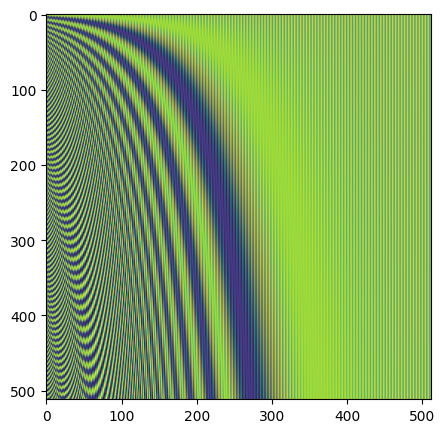

In [89]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
        super().__init__()
        # register_buffer stores pe in state_dict() and move into model cuda by itself
        # .to(device) moves nn.Parameters and buffers
        self.register_buffer('pe', self.position_encode(d_model, max_len))

    def forward(self, x):
        # x in B x T x D
        return x + self.pe[:, :x.shape[1], :] # encode up to x length

    def position_encode(self, d_model, max_len):
        # numerically stable divisor T/2 x 1
        div = torch.exp(
            -1 * torch.arange(0, d_model, 2).to(torch.float32)/d_model * math.log(10000)
        )

        # calculate encodings
        pe = torch.zeros(max_len, d_model) # T x D
        pos = torch.arange(max_len).unsqueeze(1).to(torch.float32) # T x 1
        pe[:, 0::2] = torch.sin(pos*div) # even dims
        pe[:, 1::2] = torch.cos(pos*div) # odd dims
        return pe.unsqueeze(0)

PE = PositionalEncoding(512, 512)
plt.figure(figsize=(10, 5))
plt.imshow(PE(torch.zeros((1, 512, 512))).cpu().squeeze(0).numpy())
plt.show()

#### Multi-Headed Self-Attention

Implementation of standard scaled dot product attention. Let $\mathbf{Q}, \mathbf{K} \in \mathbb{R}^{T \times D_K}$ and $\mathbf{V} \in \mathbb{R}^{T \times D_V}$. Then SDP attention is

$$
\text{Attention}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \text{softmax}\left(\frac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{D_K}}\right)\mathbf{V}
$$

- In cross-attention we pass key-values instead of $\mathbf{x}$ to get $\mathbf{K}, \mathbf{V}$
- In self-attention, $\mathbf{Q}, \mathbf{K}, \mathbf{V}$ are all the same dimension
- Original implementation applies dropout after each sublayer (i.e. after the MHA block) and before LayerNorm
- Applying dropout to attention scores themselves can help overreliance

In [90]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()

        self.n_heads = n_heads
        self.d_model = d_model
        self.d_head = self.d_model//self.n_heads
        self.div = self.d_head**0.5

        self.W_q = nn.Linear(self.d_model, self.d_model)
        self.W_k = nn.Linear(self.d_model, self.d_model)
        self.W_v = nn.Linear(self.d_model, self.d_model)
        self.W_o = nn.Linear(self.d_model, self.d_model)
        self.softmax = nn.Softmax(dim=-1)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        # print(x.shape)
        B, T, D_emb = x.shape

        # calculate Q/K/V
        Q = self.W_q(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        # want to get attention scores in form B, H, T, T
        attn_scores = Q @ K.transpose(-1, -2) / self.div
        attn_scores = self.softmax(attn_scores)
        attn_scores = self.dropout(attn_scores) # prevent overreliance on any one element
        z = attn_scores @ V
        z = z.transpose(1, 2) # B, H, T, D -> B, T, H, D
        # concatenate heads and get output
        z = z.contiguous().view(B, T, self.d_model) # contiguous to keep memory + order matching or torch doesn't like
        z = self.W_o(z)
        return z

In [91]:
model_kwargs = {
    "d_model": 512,
    "n_heads": 8,
    "dropout": 0.1
}
device = "cuda" if torch.cuda.is_available() else "cpu"
model = MultiHeadAttention(**model_kwargs)
model = model.to(device)
summary(model, (10, 512)) # verbose prevents duplicate print

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1              [-1, 10, 512]         262,656
            Linear-2              [-1, 10, 512]         262,656
            Linear-3              [-1, 10, 512]         262,656
           Softmax-4            [-1, 8, 10, 10]               0
           Dropout-5            [-1, 8, 10, 10]               0
            Linear-6              [-1, 10, 512]         262,656
Total params: 1,050,624
Trainable params: 1,050,624
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.02
Forward/backward pass size (MB): 0.17
Params size (MB): 4.01
Estimated Total Size (MB): 4.20
----------------------------------------------------------------


#### Position-wise Feed-Forward Networks

This is pretty straight-forward, the transformer authors just use a 2-layer FFN.

In [92]:
class PositionWiseFFN(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.W_1 = nn.Linear(d_model, d_ff)
        self.W_2 = nn.Linear(d_ff, d_model)

        self.relu = nn.ReLU()

    def forward(self, x):

        z = self.relu(self.W_1(x))
        z = self.W_2(z)
        return z

In [93]:
model_kwargs = {
    "d_model": 512,
    "d_ff": 2048
}
device = "cuda" if torch.cuda.is_available() else "cpu"
model = PositionWiseFFN(**model_kwargs)
model = model.to(device)
summary(model, (10, 512)) # verbose prevents duplicate print

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1             [-1, 10, 2048]       1,050,624
              ReLU-2             [-1, 10, 2048]               0
            Linear-3              [-1, 10, 512]       1,049,088
Total params: 2,099,712
Trainable params: 2,099,712
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.02
Forward/backward pass size (MB): 0.35
Params size (MB): 8.01
Estimated Total Size (MB): 8.38
----------------------------------------------------------------


#### Putting it All Together (Encoder)

In [94]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_ff = d_ff

        self.mha = MultiHeadAttention(d_model, n_heads, dropout)
        self.ln1 = nn.LayerNorm(d_model)
        self.ffn = PositionWiseFFN(d_model, d_ff)
        self.ln2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        z = self.mha(x)
        z = self.ln1(x + z) # add & norm
        z = self.ffn(z)
        z = self.ln2(x + z)
        z = self.dropout(z)
        return z


model_kwargs = {
    "d_model": 512,
    "n_heads": 8,
    "d_ff": 2048,
    "dropout": 0.1
}
device = "cuda" if torch.cuda.is_available() else "cpu"
model = TransformerEncoderLayer(**model_kwargs)
model = model.to(device)
summary(model, (10, 512)) # verbose prevents duplicate print

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1              [-1, 10, 512]         262,656
            Linear-2              [-1, 10, 512]         262,656
            Linear-3              [-1, 10, 512]         262,656
           Softmax-4            [-1, 8, 10, 10]               0
           Dropout-5            [-1, 8, 10, 10]               0
            Linear-6              [-1, 10, 512]         262,656
MultiHeadAttention-7              [-1, 10, 512]               0
         LayerNorm-8              [-1, 10, 512]           1,024
            Linear-9             [-1, 10, 2048]       1,050,624
             ReLU-10             [-1, 10, 2048]               0
           Linear-11              [-1, 10, 512]       1,049,088
  PositionWiseFFN-12              [-1, 10, 512]               0
        LayerNorm-13              [-1, 10, 512]           1,024
          Dropout-14              [-1, 

In [95]:
class TransformerEncoder(nn.Module):
    def __init__(self, d_emb, d_model, n_heads, d_ff, n_layers, max_len, dropout):
        # embedding dim does not necessarily need to match model dim
        super().__init__()

        self.d_emb = d_emb
        self.d_model = d_model
        self.d_ff = d_ff

        # embedding schtuff
        # => we don't need an embedding layer since we aren't passing in text
        self.W_proj = nn.Linear(self.d_emb, self.d_model)
        self.PE = PositionalEncoding(d_model, max_len)

        # defining the main encoder stack
        self.encoder = nn.Sequential(*[
            TransformerEncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

    def forward(self, x):
        # X in B x T
        z = self.PE(x)
        z = self.encoder(z)
        return z

model_kwargs = {
    "d_emb": 64,
    "d_model": 64,
    "n_heads": 8,
    "d_ff": 2048,
    "dropout": 0.1,
    "n_layers": 2,
    "max_len": 512
}
device = "cuda" if torch.cuda.is_available() else "cpu"
model = TransformerEncoder(**model_kwargs)
model = model.to(device)
summary(model, (128,64)) # verbose prevents duplicate print

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
PositionalEncoding-1              [-1, 128, 64]               0
            Linear-2              [-1, 128, 64]           4,160
            Linear-3              [-1, 128, 64]           4,160
            Linear-4              [-1, 128, 64]           4,160
           Softmax-5          [-1, 8, 128, 128]               0
           Dropout-6          [-1, 8, 128, 128]               0
            Linear-7              [-1, 128, 64]           4,160
MultiHeadAttention-8              [-1, 128, 64]               0
         LayerNorm-9              [-1, 128, 64]             128
           Linear-10            [-1, 128, 2048]         133,120
             ReLU-11            [-1, 128, 2048]               0
           Linear-12              [-1, 128, 64]         131,136
  PositionWiseFFN-13              [-1, 128, 64]               0
        LayerNorm-14              [-1, 

### OCR CNN-Transformer Model

In [96]:
class OCRNet(nn.Module):
    def __init__(self,
                 # CNN stuff
                 kernel, num_filters, num_in_channels, num_classes, width, height,
                 # transformer stuff
                 n_heads, d_ff, n_layers, dropout
                 ):
        super().__init__()

        # num_filters*4, W/8, H/8
        self.seq_len = width//8
        self.d_model = num_filters*4 * (height//8) # CTC scans across width looking at vertical receptive field

        self.cnn = CNN(kernel, num_filters, num_in_channels, width, height)

        self.transformer = TransformerEncoder(self.d_model, self.d_model, n_heads, d_ff, n_layers, self.seq_len, dropout)
        self.W_proj = nn.Linear(self.d_model, num_classes)

    def forward(self, x):
        # x is an image
        features = self.cnn(x) # B, C, W, H
        B, C, W, H = features.shape

        features = features.permute(0, 2, 1, 3) # B, C, W, H
        features = features.contiguous().view(B, W, C*H)
        # print(features.shape)
        z = self.transformer(features)
        z = self.W_proj(z) # B, W, Vocab size

        # https://docs.pytorch.org/docs/stable/generated/torch.nn.CTCLoss.html
        return z.transpose(0, 1) # T, B, W

model_kwargs = {
    "kernel": 3,
    "num_filters": 16,
    "num_in_channels": 3,
    "num_classes": len(Tokenizer().chars),
    "width": 64,
    "height": 64,
    "n_heads": 8,
    "d_ff": 2048,
    "n_layers": 2,
    "dropout": 0.1,
}
device = "cuda" if torch.cuda.is_available() else "cpu"
model = OCRNet(**model_kwargs)
model = model.to(device)
summary(model, (3, 64, 64)) # verbose prevents duplicate print

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 64, 64]             448
         MaxPool2d-2           [-1, 16, 32, 32]               0
       BatchNorm2d-3           [-1, 16, 32, 32]              32
              ReLU-4           [-1, 16, 32, 32]               0
            Conv2d-5           [-1, 32, 32, 32]           4,640
         MaxPool2d-6           [-1, 32, 16, 16]               0
       BatchNorm2d-7           [-1, 32, 16, 16]              64
              ReLU-8           [-1, 32, 16, 16]               0
            Conv2d-9           [-1, 64, 16, 16]          18,496
        MaxPool2d-10             [-1, 64, 8, 8]               0
      BatchNorm2d-11             [-1, 64, 8, 8]             128
             ReLU-12             [-1, 64, 8, 8]               0
              CNN-13             [-1, 64, 8, 8]               0
PositionalEncoding-14               [-1

### Loss Definition

***Connectionist Temporal Classification Loss*** is the probability of ground truth label sequence $\mathbf{l}$ conditioned on per-frame predictions $\mathbf{y} = y_1, \dots, y_T$. This avoids the need to label positions of individual characters.

- Let $\mathbf{y} = y_1, \dots, y_T$ where $T$ is sequence length
- Each $y_t \in R^{|L'|}$ is a probability distribution over the set $L' = L \bigcup \texttt{<BLANK>}$ where $L$ is the vocabulary and we add the extra `<BLANK>` label
- We define a Seq2Seq mapping (sequence collapsing) function $B$ on sequence $\pi \in L'^T$, where $B: \pi \mapsto \mathbf{l}$ by first removing repeated labels, then removing blanks
  - i.e. $B(\texttt{--hh-e-l-ll-oo--}) = \texttt{hello}$ where `-` is `<BLANK>`
- Let $y_{\pi_t}^t$ be the probability of having label $\pi_t$ at timestamp $t$
- Then, conditional CTC probability is sum of probabilities of all $\pi$ mapped by $B$ onto $\mathbf{l}$

$$
p(\mathbf{l}|\mathbf{y}) = \sum_{\pi: B(\pi) = \mathbf{l}} p(\pi|\mathbf{y}) \qquad \text{where} \qquad p(\pi|\mathbf{y}) = \prod_{t=1}^T y_{\pi_t}^t
$$

Computing $p(\mathbf{l}|\mathbf{y})$ is infeasible due to exponential number of summation items. This is because $\pi : B(\pi) = \mathbf{l}$ is exponential in $T$, i.e. for a 10-length feature sequence input to output

$$
\texttt{abc} = B(\texttt{--aa--b-cc}) = B(\texttt{-a-bbbbb-c}) = \cdots
$$

Instead, we can compute it using a *forward-backward* algortihm.

For our task, we'll use lexicon-free transcription, i.e. simply take output collapsed sequence with the most probable labels at each timestamp.
$$
\mathbf{l}^* \approx B(\text{argmax}_\pi p (\pi|\mathbf{y}))
$$

- Note, in lexicon-based transcription we would search for nearest neighbor words in our dictionary based on edit-distance

In training, this means given dataset $X = \{I_i, \mathbf{l}_i\}_i$, where $I_i$ is training image $i$ and $\mathbf{l}_i$ is the ground truth label seqeunce, we want to ***minimize negative log-likelihood of CTC conditional probability***

$$
J = -\sum_{I_i, \mathbf{l}_i \in X} \log p(\mathbf{l}_i|\mathbf{y}_i)
$$

- $\mathbf{y}_i$ is the feature sequence produced from $I_i$

In [97]:
# class CTCLoss(nn.Module):
#     def __init__(self):
#         super().__init__()

#     def forward(self, predictions, targets):
#         # we need to trace out all possible paths from T x B x V -> label
#         # this can be formulated as a dynamic programming problem, calculating iterative prefix sums

#     def step(self, )


## Training

### Dataloaders

In [98]:
# define augmentations we want to run
train_transform = v2.Compose([
    v2.ToDtype(torch.float32),
    v2.Resize((64, 64)),
    # v2.RandomRotation(20), # light rotation to avoid digits being flipped
    # v2.RandomPerspective(distortion_scale=0.2),
    # v2.ElasticTransform(alpha=20),
    # v2.ColorJitter(brightness = 0.2, hue = 0.2),
    # v2.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 0.1)),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # v2.ToTensor()
])

eval_transform = v2.Compose([
    v2.ToDtype(torch.float32),
    v2.Resize((64, 64)),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # v2.ToTensor()
])

TRAIN_SIZE = 0.8
VAL_SIZE = 0.1
TEST_SIZE = 1 - TRAIN_SIZE - VAL_SIZE

jersey_df = pl.read_csv(os.path.join(jersey_path, "train_player_numbers.csv"))
jersey_df = (
    jersey_df
    .select("filename", "label")
    .unique()
)

train_idx, test_idx = train_test_split(list(range(len(jersey_df))), train_size=TRAIN_SIZE, test_size=TEST_SIZE, random_state=SEED)
val_idx, test_idx = train_test_split(test_idx, train_size=VAL_SIZE, test_size=TEST_SIZE, random_state=SEED)

tokenizer = Tokenizer()

train_ds = JerseyDataset(
    image_dir = os.path.join(jersey_path, "train_player_numbers/"),
    df = jersey_df[train_idx],
    tokenizer = tokenizer,
    transform = train_transform
)

val_ds = JerseyDataset(
    image_dir = os.path.join(jersey_path, "train_player_numbers/"),
    df = jersey_df[val_idx],
    tokenizer = tokenizer,
    transform = eval_transform
)

test_ds = JerseyDataset(
    image_dir = os.path.join(jersey_path, "train_player_numbers/"),
    df = jersey_df[test_idx],
    tokenizer = tokenizer,
    transform = eval_transform
)

print(f"Jersey dataset size: {len(jersey_df)}")
print(f"Train size: {len(train_idx)}")
print(f"Val size: {len(val_idx)}")
print(f"Test size: {len(test_idx)}")


Jersey dataset size: 43540
Train size: 34832
Val size: 435
Test size: 436


In [99]:
# define loaders
train_kwargs = {
    'batch_size': 16384,
    'shuffle': True,
    'collate_fn': collate_fn,
    'num_workers': 2,

    # higher bandwidth transfer between host/device using page-locked ("pinned") memory - https://developer.nvidia.com/blog/how-optimize-data-transfers-cuda-cc/
    # essentially, by allocating pinned memory, we can avoid an extra transfer from page->pin in host, before -> dram in device
    'pin_memory': True
}
eval_kwargs = {
    'batch_size': 16384,
    'shuffle': False,
    'collate_fn': collate_fn,
    'num_workers': 2,
    'pin_memory': True
}

train_loader = DataLoader(train_ds, **train_kwargs)
val_loader = DataLoader(val_ds, **eval_kwargs)
test_loader = DataLoader(test_ds, **eval_kwargs)

torch.Size([435, 3, 64, 64]) torch.float32
tensor(568.0868) tensor(286.9854)
torch.Size([435, 2]) torch.int64
torch.Size([435]) torch.int64


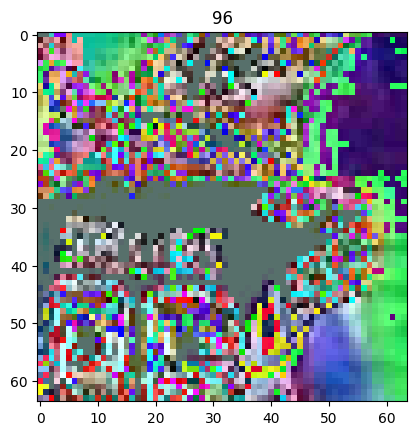

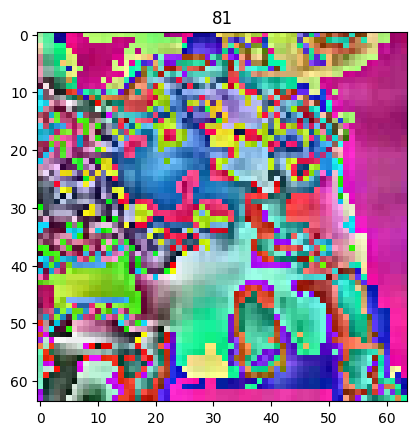

In [100]:

for image, label, seq_len in val_loader:
    # will look weird but that's just how matplotlib sees normalized tensors
    print(image.shape, image.dtype)
    print(image.mean(), image.std())
    print(label.shape, label.dtype)
    print(seq_len.shape, seq_len.dtype)


    image_0 = v2.ToPILImage()(image[0])
    plt.imshow(image[0].permute(1, 2, 0).numpy().astype(np.uint8))
    plt.title(tokenizer.decode(label[0]))
    plt.show()

    image_2 = v2.ToPILImage()(image[2])
    plt.imshow(image[30].permute(1, 2, 0).numpy().astype(np.uint8))
    plt.title(tokenizer.decode(label[30]))
    plt.show()

    break


### Training Loop

In [109]:
model_kwargs = {
    "kernel": 3,
    "num_filters": 16,
    "num_in_channels": 3,
    "num_classes": len(Tokenizer().chars),
    "width": 64,
    "height": 64,
    "n_heads": 8,
    "d_ff": 1024,
    "n_layers": 2,
    "dropout": 0.1,
}
device = "cuda" if torch.cuda.is_available() else "cpu"
train_config = {
    "num_epochs": 200,
    "learning_rate": 5e-3,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

model = OCRNet(**model_kwargs).to(train_config["device"])
with torch.no_grad():
    # set bias for token 0 to be -1 so we don't overpredict blanks
    model.W_proj.bias.fill_(0)
    model.W_proj.bias[0] = -1

criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = optim.AdamW(model.parameters(), lr=train_config["learning_rate"])

# AMP to improve speeds/memory usage benefits on lower precision data types https://pytorch.org/blog/what-every-user-should-know-about-mixed-precision-training-in-pytorch/
scaler = torch.amp.GradScaler('cuda')

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=5e-3,
    steps_per_epoch=len(train_loader),
    epochs=train_config['num_epochs'],
    pct_start=0.1 # warm up 10% epochs
)

losses = {
    "train": [],
    "val": [],
}

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipython-input-1730179547.py:6: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device=="cuda")):


  0%|          | 0/1 [00:00<?, ?it/s]

Epoch 0: {'train_loss': 6.144577662150065, 'val_loss': 3.5684003829956055, 'val_accuracy': nan}


...

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch 23: {'train_loss': 2.401912291844686, 'val_loss': 2.3106722831726074, 'val_accuracy': nan}


  0%|          | 0/3 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [111]:
for epoch in tqdm(range(train_config["num_epochs"])):
    # Pass scaler to step function
    train_loss, _ = epoch_step(model, train_loader, criterion, optimizer, train_config["device"], step_type = "train", scaler=scaler)
    # Pass tokenizer to calc accuracy
    val_loss, val_acc = epoch_step(model, val_loader, criterion, optimizer, train_config["device"], step_type = "eval", tokenizer=tokenizer)
    scheduler.step()

    # log metrics
    losses["train"].append(train_loss)
    losses["val"].append(val_loss)

    metrics = {
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
    }

    print(f"Epoch {epoch}: {metrics}")

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipython-input-1730179547.py:6: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device=="cuda")):


  0%|          | 0/1 [00:00<?, ?it/s]

Epoch 0: {'train_loss': 2.3347381750742593, 'val_loss': 2.2978103160858154, 'val_accuracy': nan}


...

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch 68: {'train_loss': 0.7402055064837137, 'val_loss': 3.109058141708374, 'val_accuracy': nan}


  0%|          | 0/3 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Evaluation

In [128]:
# train
n_correct = 0
n_total = 0
with torch.no_grad():
    for image, label, seq_len in train_loader:
        # will look weird but that's just how matplotlib sees normalized tensors
        # print(image.shape, image.dtype)
        # print(image.mean(), image.std())
        # print(label.shape, label.dtype)
        # print(seq_len.shape, seq_len.dtype)
        outputs = model(image.to(device))
        log_probs = F.log_softmax(outputs, dim=2)
        output_decoded = np.array(ctc_decode(log_probs, tokenizer))
        label_decoded = np.array([tokenizer.decode(x.cpu().numpy()) for x in label])
        n_correct += (output_decoded == label_decoded).sum().item()
        n_total += len(label_decoded)


        # image_0 = v2.ToPILImage()(image[0])
        # plt.imshow(image[0].permute(1, 2, 0).numpy().astype(np.uint8))
        # plt.title(f"Truth: {tokenizer.decode(label[0])} | Pred: {output_decoded[0]}")
        # plt.show()

        # image_2 = v2.ToPILImage()(image[2])
        # plt.imshow(image[30].permute(1, 2, 0).numpy().astype(np.uint8))
        # plt.title(f"Truth: {tokenizer.decode(label[30])} | Pred: {output_decoded[30]}")
        # plt.show()

        break
print(f"Accuracy: {n_correct/n_total}")

Accuracy: 0.5982666015625


In [129]:
# val
n_correct = 0
n_total = 0
with torch.no_grad():
    for image, label, seq_len in val_loader:
        # will look weird but that's just how matplotlib sees normalized tensors
        # print(image.shape, image.dtype)
        # print(image.mean(), image.std())
        # print(label.shape, label.dtype)
        # print(seq_len.shape, seq_len.dtype)
        outputs = model(image.to(device))
        log_probs = F.log_softmax(outputs, dim=2)
        output_decoded = np.array(ctc_decode(log_probs, tokenizer))
        label_decoded = np.array([tokenizer.decode(x.cpu().numpy()) for x in label])
        n_correct += (output_decoded == label_decoded).sum().item()
        n_total += len(label_decoded)


        # image_0 = v2.ToPILImage()(image[0])
        # plt.imshow(image[0].permute(1, 2, 0).numpy().astype(np.uint8))
        # plt.title(f"Truth: {tokenizer.decode(label[0])} | Pred: {output_decoded[0]}")
        # plt.show()

        # image_2 = v2.ToPILImage()(image[2])
        # plt.imshow(image[30].permute(1, 2, 0).numpy().astype(np.uint8))
        # plt.title(f"Truth: {tokenizer.decode(label[30])} | Pred: {output_decoded[30]}")
        # plt.show()

        break
print(f"Accuracy: {n_correct/n_total}")

Accuracy: 0.10574712643678161


In [130]:
# test
n_correct = 0
n_total = 0
with torch.no_grad():
    for image, label, seq_len in test_loader:
        # will look weird but that's just how matplotlib sees normalized tensors
        # print(image.shape, image.dtype)
        # print(image.mean(), image.std())
        # print(label.shape, label.dtype)
        # print(seq_len.shape, seq_len.dtype)
        outputs = model(image.to(device))
        log_probs = F.log_softmax(outputs, dim=2)
        output_decoded = np.array(ctc_decode(log_probs, tokenizer))
        label_decoded = np.array([tokenizer.decode(x.cpu().numpy()) for x in label])
        n_correct += (output_decoded == label_decoded).sum().item()
        n_total += len(label_decoded)


        # image_0 = v2.ToPILImage()(image[0])
        # plt.imshow(image[0].permute(1, 2, 0).numpy().astype(np.uint8))
        # plt.title(f"Truth: {tokenizer.decode(label[0])} | Pred: {output_decoded[0]}")
        # plt.show()

        # image_2 = v2.ToPILImage()(image[2])
        # plt.imshow(image[30].permute(1, 2, 0).numpy().astype(np.uint8))
        # plt.title(f"Truth: {tokenizer.decode(label[30])} | Pred: {output_decoded[30]}")
        # plt.show()

        break
print(f"Accuracy: {n_correct/n_total}")

Accuracy: 0.10779816513761468


In [131]:
list(zip(label_decoded, output_decoded))

[(np.str_('59'), np.str_('65')),
 (np.str_('64'), np.str_('95')),
 (np.str_('30'), np.str_('31')),
 (np.str_('91'), np.str_('91')),
 (np.str_('94'), np.str_('99')),
 (np.str_('93'), np.str_('89')),
 (np.str_('51'), np.str_('81')),
 (np.str_('70'), np.str_('65')),
 (np.str_('42'), np.str_('40')),
 (np.str_('45'), np.str_('40')),
 (np.str_('42'), np.str_('11')),
 (np.str_('58'), np.str_('54')),
 (np.str_('98'), np.str_('65')),
 (np.str_('17'), np.str_('76')),
 (np.str_('73'), np.str_('88')),
 (np.str_('47'), np.str_('44')),
 (np.str_('12'), np.str_('82')),
 (np.str_('77'), np.str_('88')),
 (np.str_('33'), np.str_('88')),
 (np.str_('20'), np.str_('80')),
 (np.str_('53'), np.str_('65')),
 (np.str_('26'), np.str_('66')),
 (np.str_('35'), np.str_('34')),
 (np.str_('60'), np.str_('62')),
 (np.str_('14'), np.str_('11')),
 (np.str_('59'), np.str_('22')),
 (np.str_('97'), np.str_('47')),
 (np.str_('70'), np.str_('30')),
 (np.str_('3'), np.str_('88')),
 (np.str_('79'), np.str_('69')),
 (np.str_('